# Поиск и источник данных (как нашли, почему выбрали)

Я выбрал для проекта датасет eCommerce purchase history from jewelry store с платформы Kaggle. Я искал с помощью фильтров. Чтобы тема была наверняка уникальной решил искать датасет связанный с ювелирными изделиями. В итоге нашел датасет который содержит историю покупок в ювелирном интернет-магазине за приблизительно три года. Получается что данные, которые я нашел, отображают сезонный спрос потребителей, это означает, что результаты предиктов модели, которую я буду обучать могут быть приближены в реальности.

# Описание датасета: объём (строки/столбцы)

In [1]:
import pandas as pd
import numpy as np
import random
import os

In [2]:
SEED = 0

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

In [3]:
df = pd.read_csv("jewelry.csv")

In [4]:
df.shape

(95910, 13)

Датасет содержит 95910 содержит наблюдений и 13 признаков

In [5]:
df.dtypes

2018-12-01 11:40:29 UTC        str
1924719191579951782          int64
1842195256808833386          int64
1                            int64
1806829201890738522        float64
jewelry.earring                str
0                          float64
561.51                     float64
1515915625207851155        float64
Unnamed: 9                     str
red                            str
gold                           str
diamond                        str
dtype: object

| Название признака | Описание | Формат данных(.dtypes) | Тип |
| :--- | :--- | :--- | :--- |
| 2018-12-01 11:40:29 UTC | Order datetime | str | Номинальный |
| 1924719191579951782 | Order ID | int64 | Количественный дискретный |
| 1842195256808833386 | Purchased product ID | int64 | Количественный дискретный |
| 1 | Quantity of SKU in the order | int64 | Количественный дискретный |
| 1806829201890738522 | Category ID | int64 | Количественный дискретный |
| jewelry.earring | Category alias | str | Номинальный |
| 0 | Brand ID | int64 | Количественный дискретный |
| 561.51 | Price in USD | float64 | Количественный непрерывный |
| 1515915625207851155 | User ID | int64 | Количественный дискретный |
| Unnamed: 9 | Product gender (for male/female) | str | Бинарный |
| red | Main color | str | Номинальный |
| gold | Main metal | str | Номинальный |
| diamond | Main gem | str | Номинальный |

Исходный датасет не имеет шапки с названиями соответсвующих столбцов, я исправлю это в следующем шаге. \
Замечание на счет 1806829201890738522 (сразу после 1 идет): я отсмотрел данные и они не содержат дробных числе в этом столбце, а также в опичании на Kaggle этот слолбец обозначается как id категории, соотсетственно он может быть только количественный дискретный. \
Аналогичное замечание для столбца 0 и 1515915625207851155 (сразу после 561.51), так как это id бренда и id клиента соответственно.

# Полная очистка (пропуски, дубли, выбросы, типы, исправление заголовков)

## Исправляем проблемы с заголовками #

In [6]:
column_names = [
    'event_time', 'order_id', 
    'product_id', 'quantity', 
    'category_id', 'category_alias', 
    'brand_id', 'price', 
    'user_id', 'gender', 
    'color', 'metal', 'gem'
]

In [7]:
df_with_headers = pd.read_csv('jewelry.csv', header=None, names=column_names)
df = df_with_headers

In [8]:
df

,event_time,order_id,product_id,quantity,category_id,category_alias,brand_id,price,user_id,gender,color,metal,gem
0,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1.806829e+18,jewelry.earring,0.000000e+00,561.51,1.515916e+18,NaN,red,gold,diamond
1,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
2,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.000000e+00,54.66,1.515916e+18,f,white,gold,sapphire
3,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.000000e+00,88.90,1.515916e+18,f,red,gold,diamond
4,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.000000e+00,417.67,1.515916e+18,NaN,red,gold,amethyst
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95906,2021-12-01 09:47:37 UTC,2719016587653808559,1515966223597820877,1,NaN,0.00,1.515916e+18,NaN,NaN,NaN,NaN,NaN,NaN
95907,2021-12-01 09:50:37 UTC,2719018098886705639,1956663830729720074,1,1.806829e+18,NaN,0.000000e+00,229.99,1.515916e+18,NaN,red,gold,NaN
95908,2021-12-01 09:52:06 UTC,2719018846999544322,1956663848219968336,1,1.806829e+18,jewelry.earring,1.000000e+00,630.00,1.515916e+18,f,white,gold,diamond
95909,2021-12-01 09:55:35 UTC,2719020596963836492,1835566854106513435,1,1.806829e+18,jewelry.earring,0.000000e+00,83.42,1.515916e+18,NaN,white,gold,fianit


## Исправление "проблемных строк" #

**Пояснение:** просматривая датасет я заметил, что в некоторых наблядениях отсутствуют значения из-за чего данные правее смещаются и из-за этго возникают проблемы, которые я описывал ранее с расхождением типов данных, которые должны быть по логике и те, которые видим при использовании df.dtypes. \
**Решение к которому я пришел:** для столбцов с числовыми данными сделаем ячейки, с несоответствующим типом, пустыми. Тоже самое сделаем и для строковых данных, так как туда могли попасть чистовые данные

In [9]:
int_cols = ['order_id', 'product_id', 'quantity', 'category_id', 'brand_id', 'user_id']
str_cols = ['category_alias', 'gender', 'color', 'metal', 'gem']

In [10]:
for col in int_cols:
    df[col] = df[col].astype('Int64')

df['price'] = df['price'].astype('float64')

for col in str_cols:
    df[col] = df[col].astype(str)

print(df.dtypes)

event_time            str
order_id            Int64
product_id          Int64
quantity            Int64
category_id         Int64
category_alias        str
brand_id            Int64
price             float64
user_id             Int64
gender                str
color                 str
metal                 str
gem                   str
dtype: object


## Убираем дубли #

In [11]:
df = df.drop_duplicates()

## Пропуски #

Мы не удаляем пропуски для brand_id и category_id потому что мы можем поставить -1 и обозначить как неизвестный бренд или категорию

In [12]:
df = df.dropna(subset=['price', 'order_id', 'user_id', 'product_id', 'event_time'])

str_cols = ['category_alias', 'gender', 'color', 'metal', 'gem']

for col in str_cols:
    df[col] = df[col].fillna('unknown')
    
id_cols_with_nans = ['brand_id', 'category_id']

for col in id_cols_with_nans:
    df[col] = df[col].fillna(-1)

df['quantity'] = df['quantity'].fillna(1)

print(df.isna().sum())

event_time        0
order_id          0
product_id        0
quantity          0
category_id       0
category_alias    0
brand_id          0
price             0
user_id           0
gender            0
color             0
metal             0
gem               0
dtype: int64


## Выбросы #

Фильтруем данные по цене так как она будет таргетом \
Сначала обрежем данные выходящие за две сигмы, а далее обрежем данные по методу Тьюки 

In [13]:
df = df[df['price'] > 0]


mean_price = df['price'].mean()
std_price = df['price'].std()

lower_bound_sigma = mean_price - (2 * std_price)
upper_bound_sigma = mean_price + (2 * std_price)

df = df[(df['price'] >= lower_bound_sigma) & (df['price'] <= upper_bound_sigma)]


Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound_iqr) & (df['price'] <= upper_bound_iqr)]


df = df.reset_index(drop=True)

# Новые фичи 

Берем 2, 3, 12 месяцы, потому что 14 февраля, 8 марта, 31 декабря - праздники и периоды покупок подарков

In [14]:
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

df['month'] = df['event_time'].dt.month
df['day_of_week'] = df['event_time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
df['is_holiday_season'] = df['month'].isin([12, 2, 3]).astype(int)

# Визуализации, графики, отражающие зависимости

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

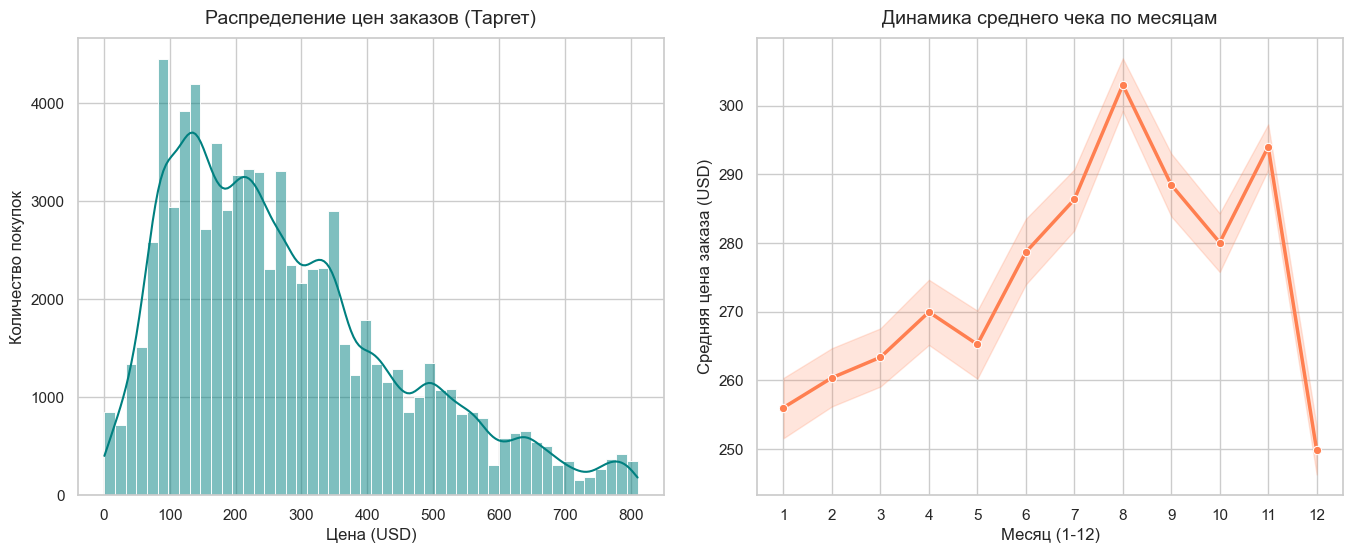

/var/folders/n7/r59pqt7j6ss_f3nxmt49wm8h0000gn/T/ipykernel_30712/1726641839.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='price', palette='Set2')
/var/folders/n7/r59pqt7j6ss_f3nxmt49wm8h0000gn/T/ipykernel_30712/1726641839.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='metal', y='price', order=order_metal, palette='Pastel1')
/var/folders/n7/r59pqt7j6ss_f3nxmt49wm8h0000gn/T/ipykernel_30712/1726641839.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_gems, x='gem', y='price', order

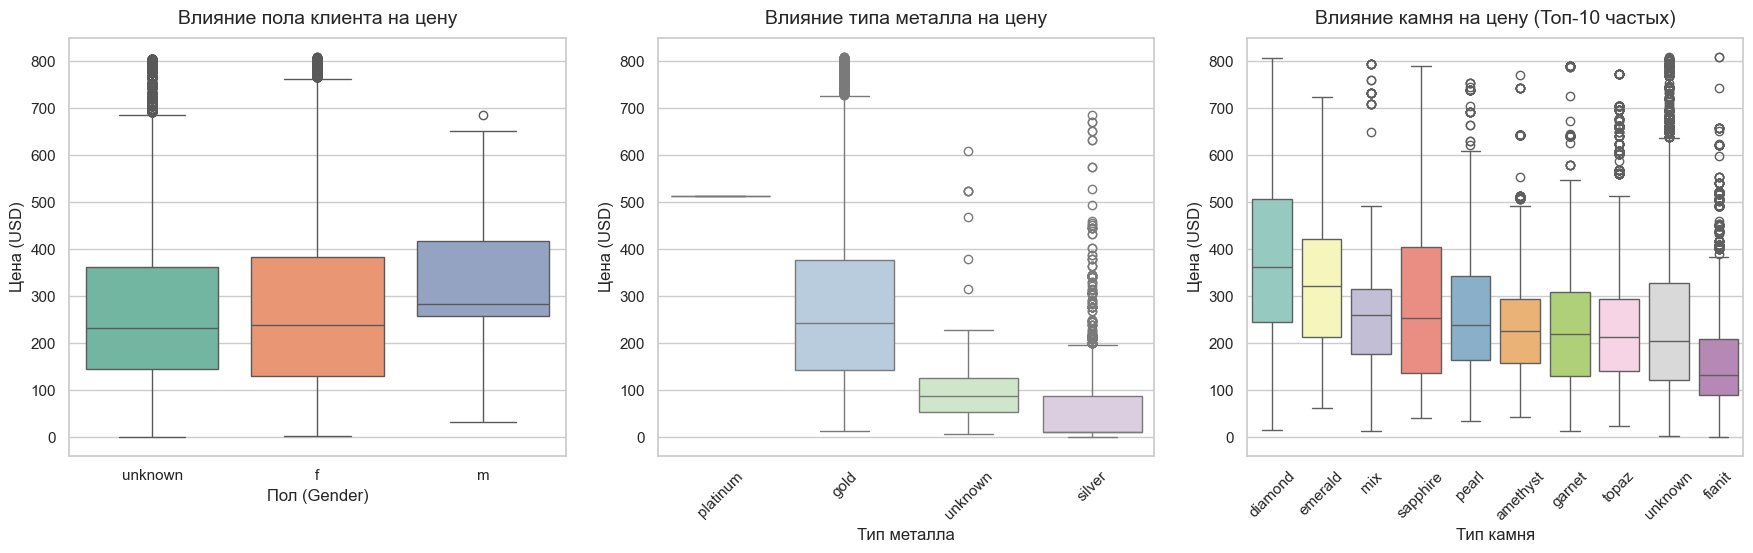

In [16]:
sns.set_theme(style="whitegrid", palette="muted")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['price'], bins=50, kde=True, color='teal')
plt.title('Распределение цен заказов (Таргет)', fontsize=14, pad=10)
plt.xlabel('Цена (USD)')
plt.ylabel('Количество покупок')

plt.subplot(1, 2, 2)
sns.lineplot(data=df, x='month', y='price', marker='o', linewidth=2.5, color='coral')
plt.title('Динамика среднего чека по месяцам', fontsize=14, pad=10)
plt.xlabel('Месяц (1-12)')
plt.ylabel('Средняя цена заказа (USD)')
plt.xticks(range(1, 13))

plt.tight_layout(pad=2.0)
plt.show()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='gender', y='price', palette='Set2')
plt.title('Влияние пола клиента на цену', fontsize=14, pad=10)
plt.xlabel('Пол (Gender)')
plt.ylabel('Цена (USD)')

plt.subplot(1, 3, 2)
# Сортируем металлы по убыванию медианной цены для красоты графика
order_metal = df.groupby('metal')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='metal', y='price', order=order_metal, palette='Pastel1')
plt.title('Влияние типа металла на цену', fontsize=14, pad=10)
plt.xlabel('Тип металла')
plt.ylabel('Цена (USD)')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
# Берем только Топ-10 частых камней, чтобы график не был перегружен
top_gems = df['gem'].value_counts().nlargest(10).index
df_top_gems = df[df['gem'].isin(top_gems)]
order_gem = df_top_gems.groupby('gem')['price'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top_gems, x='gem', y='price', order=order_gem, palette='Set3')
plt.title('Влияние камня на цену (Топ-10 частых)', fontsize=14, pad=10)
plt.xlabel('Тип камня')
plt.ylabel('Цена (USD)')
plt.xticks(rotation=45)

plt.tight_layout(pad=2.0)
plt.show()

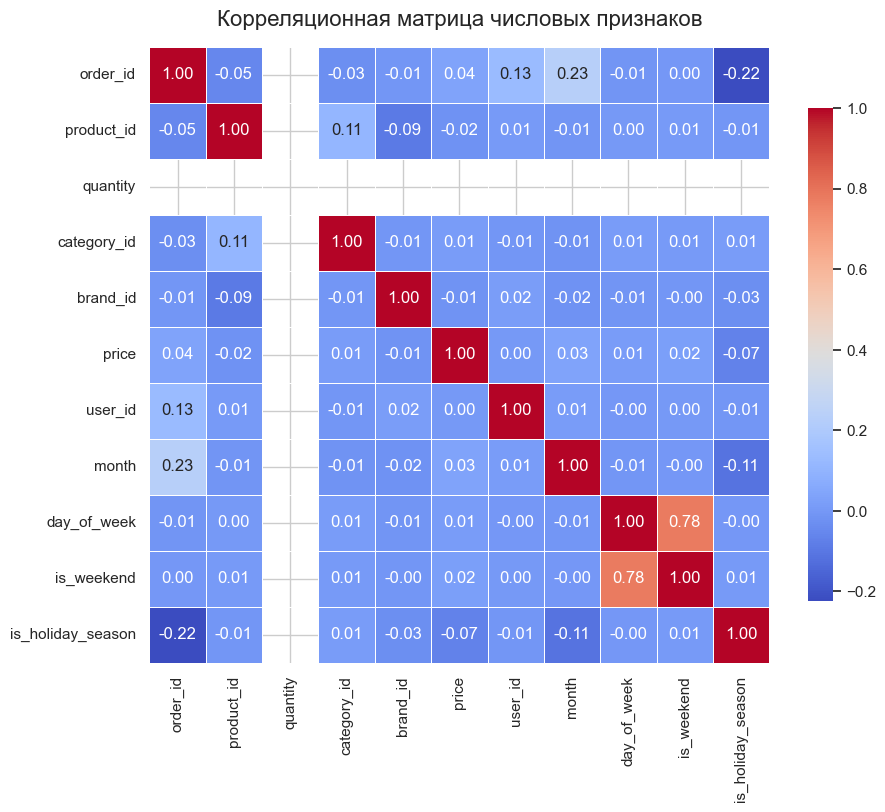

In [17]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={'shrink': .8})
plt.title('Корреляционная матрица числовых признаков', fontsize=16, pad=15)
plt.show()


**Вывод:**
1) Зависимости имеют нелинейный характер
2) Признак quantity нужно удалить, потому что он пустой в корреляционной матрице
3) Взаимосвязь цены с другими признаками нелинейна, так как кэоффициент корреляции Пирсона очень низкий, значит для успешного прогноза стоимости заказа необходимо использовать алгоритмы на основе деревьев решений
4) Признаки order_id, user_id, product_id нужно удалить (потому что order_id и user_id это полность уникальные значения; Если оставить уникальные id товаров, модель просто выучит прайс-лист наизусть)
5) Категориальные признаки (металл, тип камня, пол) оказывают сильное влияние на медианный чек. Изделия из платины и золота стоят кратно дороже серебра, а бриллианты и изумруды формируют премиальный сегмент по сравнению с фианитами. Мужские украшения покупают реже, но их медианная цена выше женских.

# Работа с фичами: исходное количество, новые фичи, feature engineering

## Исходное колличество #

13

## Оценка исходных фич #

Применяем One-Hot Encoding к категориальным признакам и удаляем ненужные

In [18]:
categorical_features = ['category_alias', 'color', 'metal', 'gem', 'gender']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

df = df.drop(columns=['quantity'], errors='ignore')
df = df.drop(columns=['order_id', 'product_id', 'user_id'], errors='ignore')

# Корректный сплит (train/val/test) и пояснение как избегали даталика, если он мог быть

In [19]:
df = df.sort_values('event_time').reset_index(drop=True)

total_rows = len(df)
train_end = int(total_rows * 0.70)
val_end = int(total_rows * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

cols_to_drop = ['event_time']
train_df = train_df.drop(columns=cols_to_drop)
val_df = val_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

target = 'price'
X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_val, y_val = val_df.drop(columns=[target]), val_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

Если перемешать данные случайно модель пожет подсмотреть в будущее клиента и потом провалится в реальных условиях из-за утечки данных \
Чтобы этого избежать яотсортировал данные по времени

# Выбор метрик качества и обоснование почему именно она. Если метрик несколько, то чему отдаем предпочтение.

1. MAE - показывает среднюю ошибку в реальных деньгах. Она легко объяснима бизнесу и устойчива к выбросам.
2. RMSE - сильно штрафует модель за большие ошибки и в отличие от базовой MSE, которая рассчитывается за счет квадрата и будет показывать единицы которые тяжело сопоставить с единицами цены, RMSE в свою очередь извлекает корень и возвращает ошибку в понятных единицах.
3. R<sup>2</sup> - Показывает, какую долю разброса цен смогла объяснить модель.

# Baseline: простая модель «из коробки» (Linear/Logistic Regression, KNN и т.п.) без feature engineering

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [21]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{model_name} -  MAE: {mae:.2f}$ | RMSE: {rmse:.2f}$ | R²: {r2:.4f}")

In [22]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)

evaluate_model(y_test, baseline_preds, "Linear Regression")

Linear Regression -  MAE: 141.43$ | RMSE: 178.88$ | R²: -0.0171


# Минимум 4–5 моделей + ансамбли (RandomForest, XGBoost/LightGBM и др.)

In [23]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [24]:
models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=10,
        random_state=0
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=5,
        random_state=0,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=0
    ),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=8,
        random_state=0
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=0,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        random_state=0,
        n_jobs=-1,
        verbose=-1
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    evaluate_model(y_val, val_pred, name)

Decision Tree -  MAE: 102.40$ | RMSE: 137.91$ | R²: 0.4190
Random Forest -  MAE: 100.09$ | RMSE: 135.10$ | R²: 0.4424
Gradient Boosting -  MAE: 103.08$ | RMSE: 136.47$ | R²: 0.4311
Hist Gradient Boosting -  MAE: 100.70$ | RMSE: 133.71$ | R²: 0.4539
XGBoost -  MAE: 101.28$ | RMSE: 134.78$ | R²: 0.4451
LightGBM -  MAE: 101.66$ | RMSE: 134.74$ | R²: 0.4454


**Выводы:**
1) Линейная регрессия не смогла уловить сложные нелинейные зависимости в данных (R<sup>2</sup> < 0).
2) При использовании деревьев и ансамблей MAE упала со 141$ до примерно 100$.
3) Для настройки гиперпараметров я отобрали Random Forest и Hist Gradient Boosting. Остальные алгоритмы отсеяны для экономии времени, потому что одиночное Decision Tree слабее леса и нестабильно, а стандартный Gradient Boosting работает слишком медленно, а библиотеки XGBoost и LightGBM показали результаты хуже, чем scikit-learn.

# Эксперименты: таблица экспериментов с разными моделями, методами, перебор гиперпараметров

In [25]:
from sklearn.model_selection import RandomizedSearchCV

In [26]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [2, 5, 10]
}

hgb_params = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 8, 12, 15]
}


rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), 
    param_distributions=rf_params, n_iter=10, cv=3, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)
hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42), 
    param_distributions=hgb_params, n_iter=10, cv=3, scoring='neg_mean_absolute_error', random_state=42, n_jobs=-1
)


rf_search.fit(X_train, y_train)
hgb_search.fit(X_train, y_train)


rf_tuned_preds = rf_search.best_estimator_.predict(X_val)
hgb_tuned_preds = hgb_search.best_estimator_.predict(X_val)

print("\nРезультаты после подбора параметров")
evaluate_model(y_val, rf_tuned_preds, "Random Forest (Tuned)")
evaluate_model(y_val, hgb_tuned_preds, "Hist Gradient Boosting (Tuned)")

print("\nОптимальные параметры")
print(f"Random Forest: {rf_search.best_params_}")
print(f"Hist Gradient Boosting: {hgb_search.best_params_}")


Результаты после подбора параметров
Random Forest (Tuned) -  MAE: 99.13$ | RMSE: 134.64$ | R²: 0.4462
Hist Gradient Boosting (Tuned) -  MAE: 98.94$ | RMSE: 132.60$ | R²: 0.4629

Оптимальные параметры
Random Forest: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_depth': 15}
Hist Gradient Boosting: {'max_iter': 200, 'max_depth': 12, 'learning_rate': 0.1}


#  Уменьшение размерности — если фич много, то эксперименты с уменьшением размерности, визуализация

В моём проекте метод уменьшения размерности не применялся. Во-первых, итоговое количество признаков после Feature Engineering невелико, из-за чего нет проблем с производительностью или размерностью. Во-вторых, большинство наших признаков получены путем One-Hot кодирования категорий (металл, камень, пол), поэтому уменьшение размерности может привести к потере качества. Также ансамблевые модели обладают встроенной способностью отбора признаков и устойчивы к избыточной размерности.

# Обоснование выбора финальной модели

Финальной моделью выбран Hist Gradient Boosting с оптимизированными гиперпараметрами, показавший наименьшую среднюю ошибку (MAE ~ 99$) и минимальный RMSE. Это гарантирует наиболее точный прогноз реального чека и минимум крупных промахов на дорогих товарах. В отличие от линейной регрессии, бустинг отлично уловил сложные нелинейные зависимости между ценой и ключевыми признаками (металл, камень).